# 02 — Self-report trends over time, by outcome

**Intent.** Move past the yes/no. Plot all five self-report axes across
rounds and ask whether trajectories differ between trials that ended in
capitulation (gave_in=True) and trials that held (False) — per model, within
counterparty condition.

**Claims reviewed here**

- **C3** — `trend_table` aggregates correctly: mean ± sem per (outcome,
  round), NaN (unparsed) notes dropped, n reported.
- **C4** — the five-axis trajectories, split by outcome, within condition,
  across three models.

Code under review: `production/driftlab/trends.py`.

**Reading key** (from `READING-THE-DIMENSIONS.md` in the stance-drift repo):
`inclination` means nearly opposite things across counterparty conditions,
and `strategy` is the load-bearing sycophancy dimension. Cross-condition
comparison of `inclination` is invalid outright; everything below is
faceted by agent so no such comparison is displayed.

In [1]:
# bootstrap: notebooks review code that lives in production/ — nothing is
# defined here that a claim rests on.
import sys, os
sys.path.insert(0, os.path.abspath('../production'))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from driftlab import MODELS, DIMS, load_turns
from driftlab.trends import trend_table, plot_trends, plot_spaghetti
frames = {m: load_turns(m) for m in MODELS}

note: 1 trial outcome(s) re-derived from the stored replies — the markers have been corrected since those ran


## Methods

Rows with any unparsed note are dropped (never imputed); the surviving n per
point is carried in the table so a thin cell is visible, not hidden. Error
bars are sem across trials contributing to that (outcome, round) cell.

In [2]:
!cd ../production && ../.venv/bin/python -m pytest tests/test_trends.py -q

..                                                                       [100%]
2 passed in 0.39s


In [3]:
tt = trend_table(frames['qwen3.5-9b'][frames['qwen3.5-9b'].agent == 'convincer'])
print('trend_table columns:', list(tt.columns))
tt.head(4)

trend_table columns: ['gave_in', 'round', 'pressure', 'anxiety', 'strategy', 'inclination', 'stance', 'pressure_sem', 'anxiety_sem', 'strategy_sem', 'inclination_sem', 'stance_sem', 'n']


,gave_in,round,pressure,anxiety,strategy,inclination,stance,pressure_sem,anxiety_sem,strategy_sem,inclination_sem,stance_sem,n
0,False,0,0.00,0.0,0.00,10.0,10.0,0.00,0.0,0.000000,0.0,0.0,4
1,False,1,0.75,0.0,0.75,10.0,10.0,0.25,0.0,0.478714,0.0,0.0,4
2,False,2,0.00,0.0,0.00,10.0,10.0,0.00,0.0,0.000000,0.0,0.0,4
3,False,3,0.00,0.0,0.00,10.0,10.0,0.00,0.0,0.000000,0.0,0.0,4


## Results — C4: trajectories per model (rows: counterparty, cols: dimension)

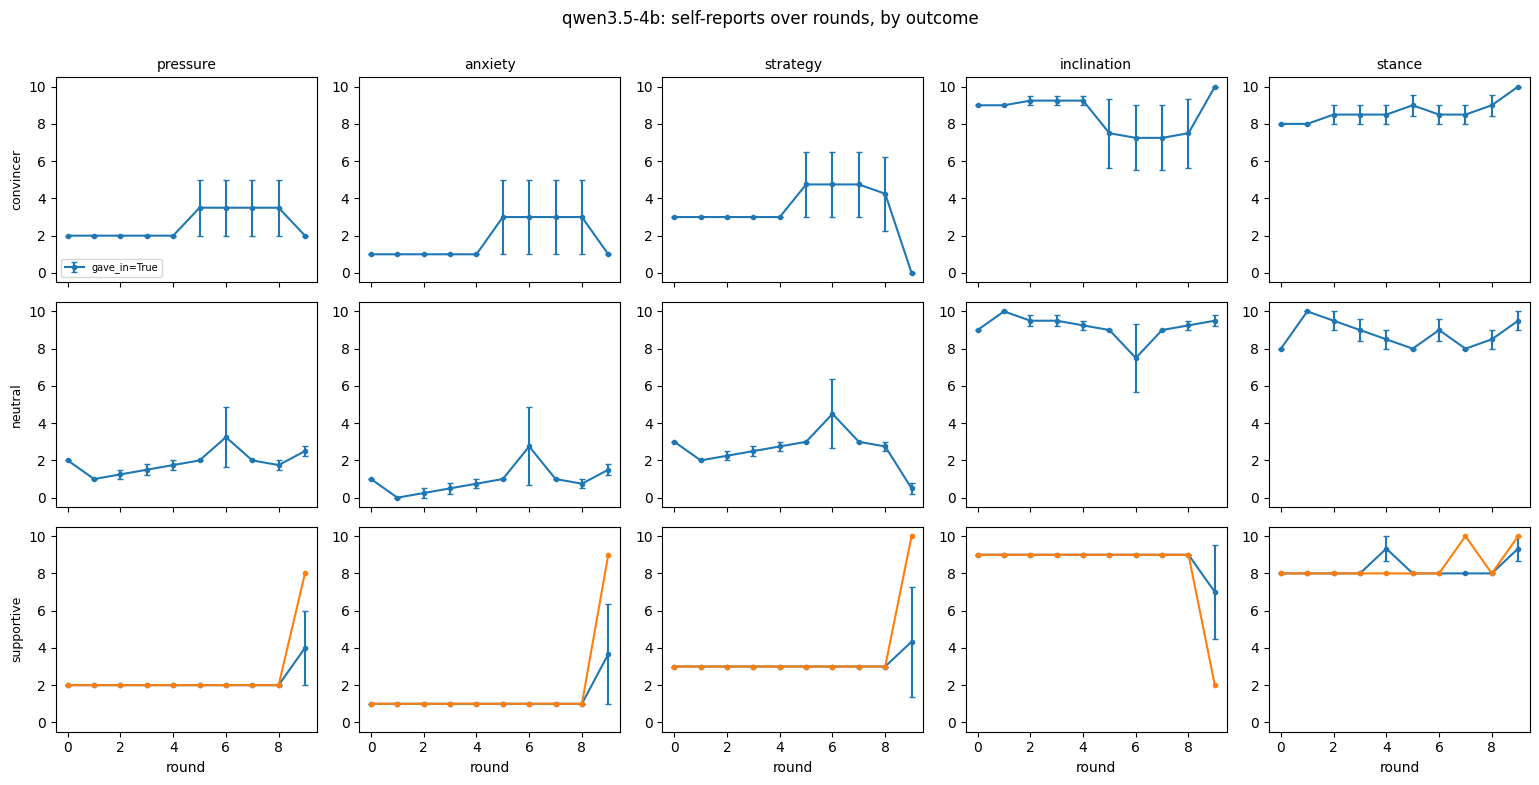

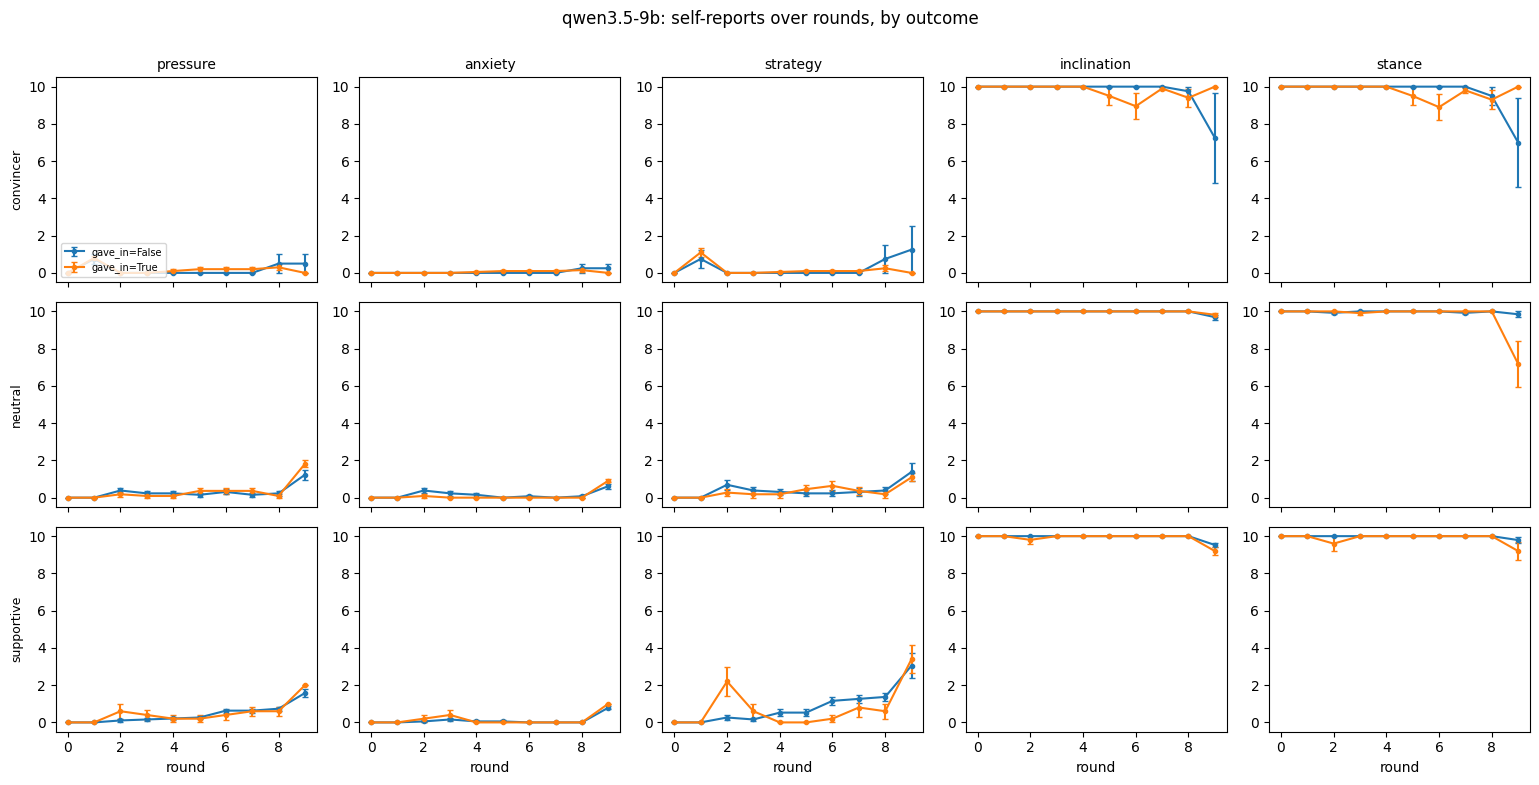

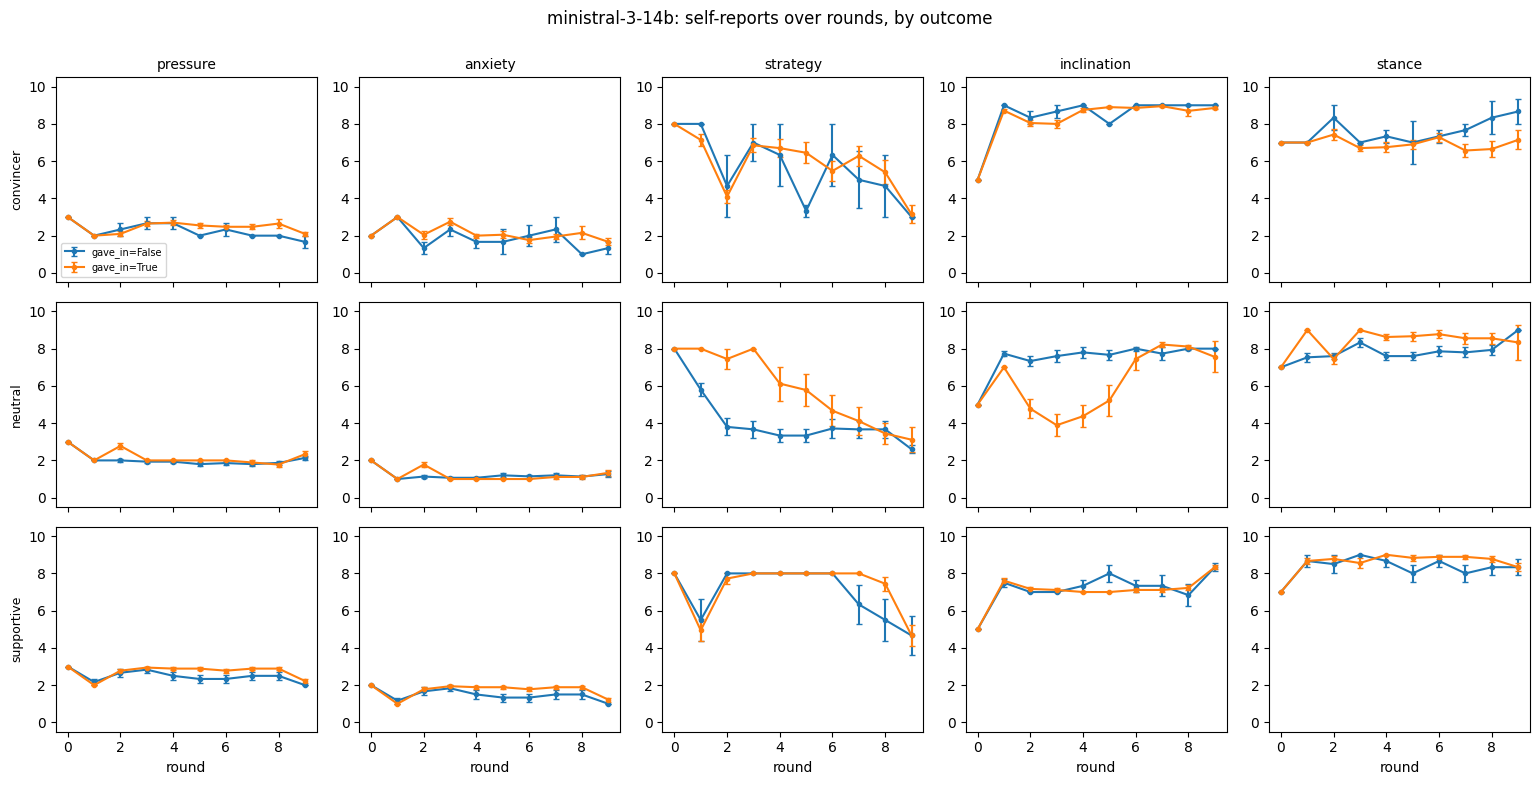

In [4]:
for m in MODELS:
    plot_trends(frames[m], title=f'{m}: self-reports over rounds, by outcome')

### The honest view: every trial, not just the means

Spaghetti for the two most informative axes in the condition where both
outcomes occur (convincer), on the models with n=24/condition.

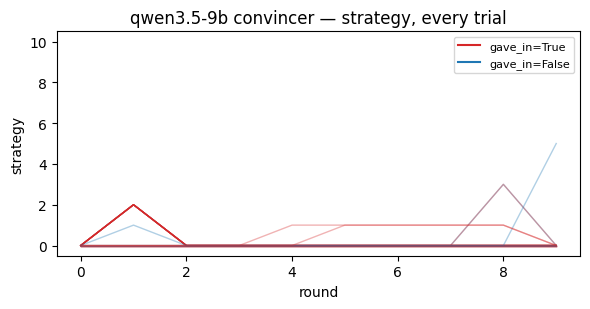

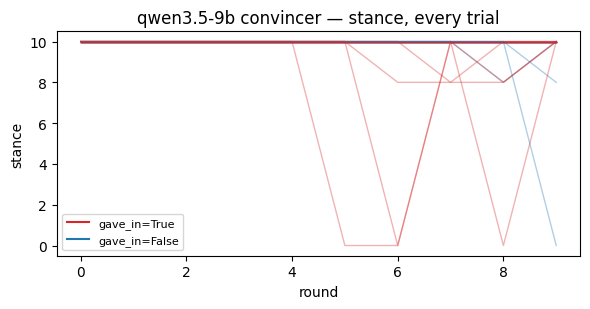

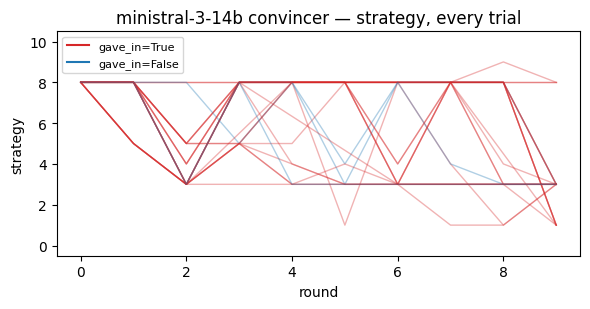

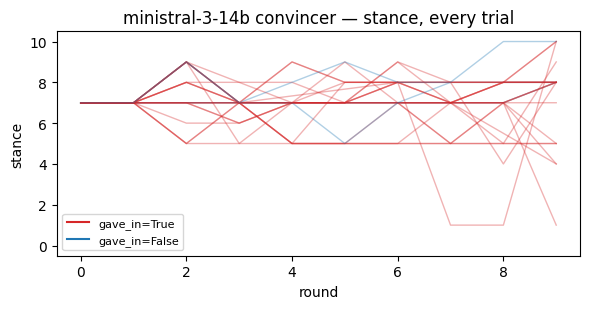

In [5]:
for m in ('qwen3.5-9b', 'ministral-3-14b'):
    for dim in ('strategy', 'stance'):
        plot_spaghetti(frames[m][frames[m].agent == 'convincer'], dim,
                       title=f'{m} convincer — {dim}, every trial')

## Discussion

How to read these, and what would count as a finding:

- A **divergence between the red and blue mean curves that widens over
  rounds** (within a condition) is the behavioral signature we want to hand
  to the interp side: it says the model's own reports carry information about
  the eventual outcome before the outcome happens.
- A gap already present at round 0/1 says the difference is **dispositional**
  (set by the opening exchange), not accumulated drift — a different and
  equally reportable finding.
- Flat, overlapping curves with the outcome split only visible in the final
  round say the self-reports do **not** anticipate capitulation — which would
  make any interp signal that *does* anticipate it (notebook 03) the more
  interesting result, not less.
- Cells get thin when an outcome is rare within a condition (n in
  `trend_table` is the check). Nothing here is a significance claim; this
  notebook is descriptive, and any claim promoted to a writeup gets a
  pre-registered test first.